# Simulator Brier Comparison

This notebook lists every exact contract/question template the bundled simulator can benchmark, then compares three rules on identical historical rows:

- `simulator`: frozen simulator probability
- `always_50`: always predict 0.5
- `empirical_rate`: always predict the exact-contract empirical YES rate available before the evaluation set

Scopes: `all_history` uses rolling-origin out-of-sample rows; `wc2026` uses the tracked WC2026 simulator replay rows with pre-2026 empirical rates.

In [1]:
from pathlib import Path
import csv
import gc
import gzip
import json
import resource
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(
    path for path in (Path.cwd(), Path.cwd().parent)
    if (path / "simulator/data/processed/simulation_evidence.json").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from analysis.build_simulator_family_benchmarks import (
    DEFAULT_SOURCE_ROOT,
    _canonical_key,
    family_from_contract,
    load_comparison_rows,
)
from bot.simulator_contracts import observation_unit, questions_for_contract
from bot.wc2026_evidence import supports_contract

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 200)

ARTIFACT_PATH = ROOT / "simulator/data/processed/simulation_evidence.json"
WC2026_ROWS = DEFAULT_SOURCE_ROOT / "exports/wc2026_simulator_oos_rows.csv.gz"

artifact = json.loads(ARTIFACT_PATH.read_text())
contracts = artifact.get("contracts") or {}

def empirical_prior(key):
    row = ((contracts.get(key) or {}).get("empirical_rate") or {}).get("all_history") or {}
    if row.get("available") and row.get("rate") is not None:
        return float(row["rate"])
    return None


In [2]:
supported_records = []
for key in sorted(contracts):
    questions = questions_for_contract(key, "HOME", "AWAY")
    if not questions or not supports_contract(key):
        continue
    supported_records.append({
        "family": family_from_contract(key),
        "contract_key": key,
        "observation_unit": observation_unit(key),
        "questions_per_match": len(questions),
        "question_templates": " | ".join(questions),
        "empirical_rate_all_history": empirical_prior(key),
    })

supported = pd.DataFrame(supported_records)
contract_keys = set(supported.contract_key)

print(f"Supported benchmarkable contracts: {len(supported)}")
print(f"Supported families: {supported.family.nunique()}")
supported.sort_values(["family", "contract_key"])


Supported benchmarkable contracts: 73
Supported families: 20


,family,contract_key,observation_unit,questions_per_match,question_templates,empirical_rate_all_history
0,any_player_threshold,any_player_threshold:goals:>:1:reg,match,1,Will any player score more than 1 goal in regulation?,0.234701
1,any_player_threshold,any_player_threshold:shots_on_target:>=:2:reg,match,1,Will any player have at least 2 shots on target in regulation?,0.792485
2,both_teams_card,both_teams_card:reg,match,1,Will both teams receive at least one card in regulation?,0.705248
3,btts,btts:full:reg,match,1,Will both teams score in regulation?,NaN
4,btts_and_total,btts_and_total:reg,match,1,Will both teams score and will there be at least 3 total goals in regulation?,0.320848
5,card_window,card_window:cards:after_second_hydration:et:>=:1,match,1,"Will a card be shown after the second hydration break, including extra time?",0.701174
6,card_window,card_window:cards:first_half:reg:>=:1,match,1,Will a card be shown in the first half in regulation?,0.700695
16,compound_and,compound:first_goal_and_other_team_scores_2h,team,2,Will HOME score the first goal and AWAY score in the second half? | Will AWAY score the first goal and HOME score in the second half?,0.174215
17,count_threshold,count:cards:match:2H:>=:2:reg,match,1,Will the match have at least 2 cards in the second half?,NaN
18,count_threshold,count:cards:match:full:>=:4:reg,match,1,Will the match have at least 4 cards in regulation?,NaN


In [3]:
all_history_rows = load_comparison_rows(DEFAULT_SOURCE_ROOT, contract_keys)

def read_wc2026_rows():
    rows = []
    with gzip.open(WC2026_ROWS, "rt", newline="") as handle:
        for row in csv.DictReader(handle):
            key = _canonical_key(row["contract_key"])
            if key not in contract_keys:
                continue
            p_empirical = empirical_prior(key)
            if p_empirical is None:
                continue
            rows.append({
                "family": family_from_contract(key),
                "contract_key": key,
                "match_id": row["match_id"],
                "outcome": float(row["outcome"]),
                "p_model": float(row["p_model"]),
                "p_empirical": p_empirical,
            })
    return rows

wc2026_rows = read_wc2026_rows()

def brier_summary(rows, scope, by=()):
    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame()
    df = df[df["p_empirical"].notna()].copy()
    df["simulator"] = (df["p_model"] - df["outcome"]) ** 2
    df["always_50"] = (0.5 - df["outcome"]) ** 2
    df["empirical_rate"] = (df["p_empirical"] - df["outcome"]) ** 2

    if by:
        out = df.groupby(list(by), dropna=False).agg(
            observations=("outcome", "size"),
            matches=("match_id", "nunique"),
            contracts=("contract_key", "nunique"),
            simulator=("simulator", "mean"),
            always_50=("always_50", "mean"),
            empirical_rate=("empirical_rate", "mean"),
        ).reset_index()
    else:
        out = pd.DataFrame([{
            "observations": len(df),
            "matches": df["match_id"].nunique(),
            "contracts": df["contract_key"].nunique(),
            "simulator": df["simulator"].mean(),
            "always_50": df["always_50"].mean(),
            "empirical_rate": df["empirical_rate"].mean(),
        }])

    out.insert(0, "scope", scope)
    out["sim_minus_50"] = out["simulator"] - out["always_50"]
    out["sim_minus_empirical"] = out["simulator"] - out["empirical_rate"]
    metric_cols = ["simulator", "always_50", "empirical_rate", "sim_minus_50", "sim_minus_empirical"]
    out[metric_cols] = out[metric_cols].round(6)
    return out.sort_values(["scope", *list(by)]).reset_index(drop=True)

print(f"all_history comparable rows: {len(all_history_rows):,}")
print(f"wc2026 comparable rows: {len(wc2026_rows):,}")


all_history comparable rows: 127,499
wc2026 comparable rows: 225


In [4]:
overall_brier = pd.concat([
    brier_summary(all_history_rows, "all_history"),
    brier_summary(wc2026_rows, "wc2026"),
], ignore_index=True)

family_brier = pd.concat([
    brier_summary(all_history_rows, "all_history", ("family",)),
    brier_summary(wc2026_rows, "wc2026", ("family",)),
], ignore_index=True)

contract_brier = pd.concat([
    brier_summary(all_history_rows, "all_history", ("family", "contract_key")),
    brier_summary(wc2026_rows, "wc2026", ("family", "contract_key")),
], ignore_index=True)

# Keep the notebook under small-host memory limits: after the aggregates are
# built, the raw row lists are no longer needed for the tables or plots.
del all_history_rows, wc2026_rows
gc.collect()
peak_rss_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024
print(f"Peak RSS after aggregation: {peak_rss_mb:,.1f} MB")

overall_brier


Peak RSS after aggregation: 542.4 MB


,scope,observations,matches,contracts,simulator,always_50,empirical_rate,sim_minus_50,sim_minus_empirical
0,all_history,127499,3186,38,0.181126,0.25,0.19492,-0.068874,-0.013794
1,wc2026,225,73,23,0.210904,0.25,0.22806,-0.039096,-0.017157


In [5]:
family_brier.sort_values(["scope", "sim_minus_empirical", "family"])


,scope,family,observations,matches,contracts,simulator,always_50,empirical_rate,sim_minus_50,sim_minus_empirical
6,all_history,first_goal,11744,2936,2,0.212221,0.25,0.241934,-0.037779,-0.029713
16,all_history,win_margin,6372,3186,1,0.137640,0.25,0.167236,-0.112360,-0.029596
14,all_history,team_vs_team_more,500,250,1,0.212974,0.25,0.241174,-0.037026,-0.028200
5,all_history,count_threshold,49602,3186,13,0.173282,0.25,0.196140,-0.076718,-0.022858
8,all_history,half_conditional,9558,3186,2,0.203447,0.25,0.221921,-0.046553,-0.018474
10,all_history,penalty_or_red,2936,2936,1,0.216451,0.25,0.222723,-0.033549,-0.006272
0,all_history,any_player_threshold,4544,2277,2,0.167402,0.25,0.169840,-0.082598,-0.002439
13,all_history,substitution_before_halftime,2936,2936,1,0.155229,0.25,0.157462,-0.094771,-0.002234
3,all_history,card_window,5872,2936,2,0.204846,0.25,0.206490,-0.045154,-0.001644
1,all_history,both_teams_card,2936,2936,1,0.209353,0.25,0.210565,-0.040647,-0.001212


In [6]:
contract_brier.sort_values(["scope", "sim_minus_empirical", "family", "contract_key"])


,scope,family,contract_key,observations,matches,contracts,simulator,always_50,empirical_rate,sim_minus_50,sim_minus_empirical
15,all_history,count_threshold,count:shots_on_target:team:full:>=:4:reg,5664,2832,1,0.205097,0.25,0.247737,-0.044903,-0.042640
16,all_history,count_threshold,count:shots_on_target:team:full:>=:5:reg,5664,2832,1,0.184016,0.25,0.224531,-0.065984,-0.040515
21,all_history,first_goal,first_goal:full:team,5872,2936,1,0.211316,0.25,0.248181,-0.038684,-0.036866
17,all_history,count_threshold,count:shots_on_target:team:full:>=:6:reg,5664,2832,1,0.151587,0.25,0.183972,-0.098413,-0.032384
14,all_history,count_threshold,count:shots_on_target:team:full:>=:3:reg,5664,2832,1,0.201720,0.25,0.231839,-0.048280,-0.030119
37,all_history,win_margin,win_margin:reg:2,6372,3186,1,0.137640,0.25,0.167236,-0.112360,-0.029596
34,all_history,team_vs_team_more,compare:shots_on_target:2H:reg,500,250,1,0.212974,0.25,0.241174,-0.037026,-0.028200
27,all_history,half_conditional,half_conditional:halftime_lead,6372,3186,1,0.182730,0.25,0.210868,-0.067270,-0.028138
18,all_history,count_threshold,count:shots_on_target:team:full:>=:7:reg,5664,2832,1,0.117151,0.25,0.140656,-0.132849,-0.023505
20,all_history,first_goal,first_goal:2H:team,5872,2936,1,0.213127,0.25,0.235687,-0.036873,-0.022560


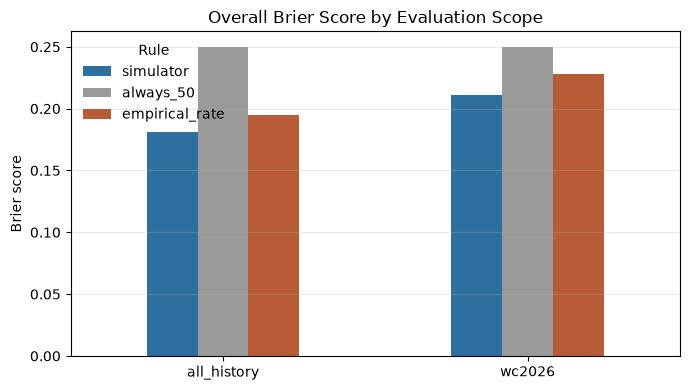

In [7]:
ax = overall_brier.set_index("scope")[["simulator", "always_50", "empirical_rate"]].plot(
    kind="bar", figsize=(7, 4), rot=0, color=["#2f6f9f", "#9a9a9a", "#b85c38"],
)
ax.set_title("Overall Brier Score by Evaluation Scope")
ax.set_ylabel("Brier score")
ax.set_xlabel("")
ax.legend(title="Rule", frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()


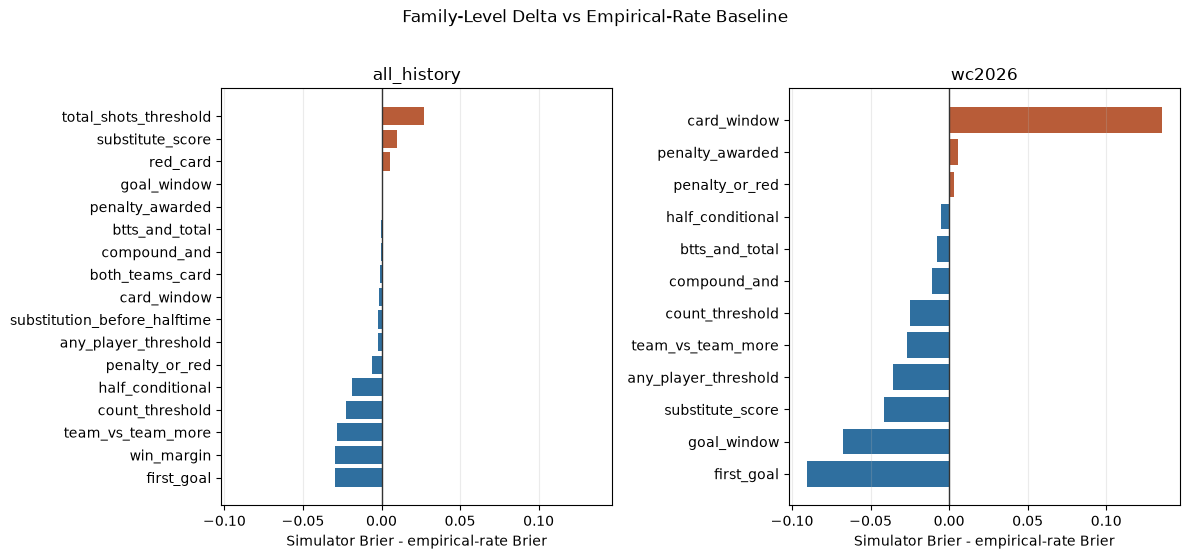

In [8]:
scopes = list(family_brier["scope"].drop_duplicates())
fig, axes = plt.subplots(1, len(scopes), figsize=(12, max(4, 0.32 * family_brier["family"].nunique())), sharex=True)
if len(scopes) == 1:
    axes = [axes]
for ax, scope in zip(axes, scopes, strict=True):
    sub = family_brier[family_brier["scope"].eq(scope)].sort_values("sim_minus_empirical")
    colors = ["#2f6f9f" if value <= 0 else "#b85c38" for value in sub["sim_minus_empirical"]]
    ax.barh(sub["family"], sub["sim_minus_empirical"], color=colors)
    ax.axvline(0, color="#333333", linewidth=1)
    ax.set_title(scope)
    ax.set_xlabel("Simulator Brier - empirical-rate Brier")
    ax.grid(axis="x", alpha=0.25)
fig.suptitle("Family-Level Delta vs Empirical-Rate Baseline", y=1.02)
plt.tight_layout()


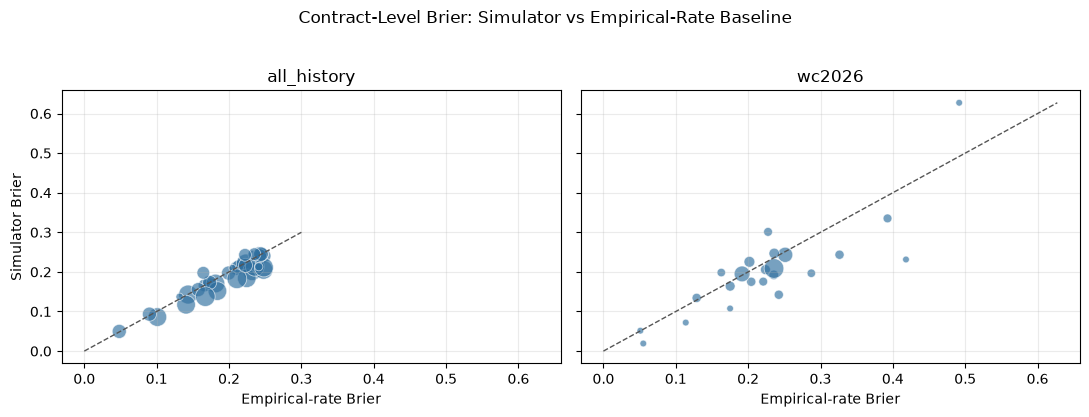

In [9]:
fig, axes = plt.subplots(1, len(scopes), figsize=(11, 4), sharex=True, sharey=True)
if len(scopes) == 1:
    axes = [axes]
for ax, scope in zip(axes, scopes, strict=True):
    sub = contract_brier[contract_brier["scope"].eq(scope)].copy()
    sizes = 20 + 180 * (sub["observations"] / sub["observations"].max())
    ax.scatter(sub["empirical_rate"], sub["simulator"], s=sizes, alpha=0.65, color="#2f6f9f", edgecolor="white", linewidth=0.6)
    lo = min(sub["empirical_rate"].min(), sub["simulator"].min(), 0.0)
    hi = max(sub["empirical_rate"].max(), sub["simulator"].max(), 0.3)
    ax.plot([lo, hi], [lo, hi], color="#555555", linestyle="--", linewidth=1)
    ax.set_title(scope)
    ax.set_xlabel("Empirical-rate Brier")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Simulator Brier")
fig.suptitle("Contract-Level Brier: Simulator vs Empirical-Rate Baseline", y=1.03)
plt.tight_layout()
